# Car AI Project - Training Linear Regression

## 1. Libraries

In [0]:
import joblib
import numpy as np
import pandas as pd

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import matplotlib.pyplot as plt
import seaborn as sns

# MLflow
import mlflow
import mlflow.sklearn
from mlflow.models import infer_signature

In [0]:
# Import project configuration
import sys
import os

# Add parent directory to path to import config
sys.path.append("..")
from config import *

print("PROJECT CONFIGURATION LOADED")
print(f"\nBASE_PATH: {BASE_PATH}")
print(f"\nData Paths:")
print(f"   - RAW_DATA_PATH: {RAW_DATA_PATH}")
print(f"   - FEATURES_PATH: {FEATURES_PATH}")
print(f"   - PROCESSED_DATA_PATH: {PROCESSED_DATA_PATH}")
print(f"   - TRAIN_TEST_PATH: {TRAIN_TEST_PATH}")
print(f"   - METRICS_PATH: {METRICS_PATH}")
print(f"\nModel Path:")
print(f"   - MODEL_PATH: {MODEL_PATH}")
print(f"\nUnity Catalog:")
print(f"   - SOURCE_CSV_FILE: {SOURCE_CSV_FILE}")
print(f"   - RAW_CARS_TABLE: {RAW_CARS_TABLE}")
print(f"   - CLEANED_CARS_TABLE: {CLEANED_CARS_TABLE}")

PROJECT CONFIGURATION LOADED

BASE_PATH: /Workspace/Users/maria.petralia@gmail.com/CarAIProject

Data Paths:
   - RAW_DATA_PATH: /Workspace/Users/maria.petralia@gmail.com/CarAIProject/data/raw
   - FEATURES_PATH: /Workspace/Users/maria.petralia@gmail.com/CarAIProject/data/features
   - PROCESSED_DATA_PATH: /Workspace/Users/maria.petralia@gmail.com/CarAIProject/data/processed
   - TRAIN_TEST_PATH: /Workspace/Users/maria.petralia@gmail.com/CarAIProject/data/train_test
   - METRICS_PATH: /Workspace/Users/maria.petralia@gmail.com/CarAIProject/data/metrics

Model Path:
   - MODEL_PATH: /Workspace/Users/maria.petralia@gmail.com/CarAIProject/models

Unity Catalog:
   - SOURCE_CSV_FILE: /Volumes/workspace/caraiproject/caraiproject/Cars_Datasets_2025.csv
   - RAW_CARS_TABLE: workspace.caraiproject.raw_cars_data_gathered
   - CLEANED_CARS_TABLE: workspace.caraiproject.cleaned_cars_data


#### Set MLflow Experiment

In [0]:
# Set MLflow experiment
mlflow.set_experiment("/Users/maria.petralia@gmail.com/CarAIProject_Experiments")

print("MLflow experiment set to: CarAIProject_Experiments")

MLflow experiment set to: CarAIProject_Experiments


In [0]:
# Set the catalog for Models
catalog = "workspace.caraiproject"

## 2. Training Linear Regression (log price)

### 2.1 Load Data and Pipeline (log_price)

In [0]:
X_train = joblib.load(os.path.join(TRAIN_TEST_PATH, "X_train_lr.pkl"))
X_test = joblib.load(os.path.join(TRAIN_TEST_PATH, "X_test_lr.pkl"))
y_train = joblib.load(os.path.join(TRAIN_TEST_PATH, "y_train_lr.pkl"))
y_test = joblib.load(os.path.join(TRAIN_TEST_PATH, "y_test_lr.pkl"))

model_lr = joblib.load(os.path.join(TRAIN_TEST_PATH, "pipeline_lr.pkl"))

numerical_features = joblib.load(os.path.join(FEATURES_PATH, "numerical_features_lr.pkl"))
categorical_features = joblib.load(os.path.join(FEATURES_PATH, "categorical_features_lr.pkl"))
binary_features = joblib.load(os.path.join(FEATURES_PATH, "binary_features_lr.pkl"))

In [0]:
display(X_train)

make,acc_0_100_min,acc_0_100_max,acc_0_100_mean,acc_0_100_is_range,acc_0_100_is_instant,is_commercial,horsepower_min,horsepower_max,horsepower_mean,horsepower_is_range,top_speed_kmh,seats,torque_nm,is_ev,is_hybrid,is_phev,fuel_macro,segment,is_luxury_brand,is_performance_luxury_brand,is_premium_brand,acceleration_class,hp_class,performance_score,acc_missing_flag,hp_bin
Jeep,7.3,7.3,7.3,0,0,0,240.0,240.0,240.0,0,200.0,5.0,270,0,1,0,Hybrid,SUV,0,0,0,Medium,Medium,21.4,0,1.0
Ford,11.0,11.0,11.0,0,0,0,140.0,140.0,140.0,0,180.0,5.0,225,0,0,0,Petrol,SUV,0,0,0,Slow,Low,7.050000000000001,0,0.0
Volkswagen,7.8,7.8,7.8,0,0,0,150.0,200.0,175.0,1,220.0,5.0,320,0,0,0,Petrol,SUV,0,0,0,Medium,Medium,15.099999999999998,0,1.0
GMC,6.7,6.7,6.7,0,0,0,420.0,420.0,420.0,0,190.0,6.0,624,0,0,0,Petrol,Sportscar,0,0,0,Medium,High,43.44,0,3.0
Volvo,22.0,22.0,22.0,0,0,0,180.0,180.0,180.0,0,80.0,2.0,800,0,0,0,Diesel,Other,0,0,1,Slow,Medium,4.800000000000001,0,1.0
Mazda,8.0,8.0,8.0,0,0,0,135.0,135.0,135.0,0,190.0,4.0,210,0,0,0,Petrol,Other,0,0,0,Slow,Low,9.5,0,0.0
Mitsubishi,9.5,9.5,9.5,0,0,0,181.0,181.0,181.0,0,190.0,7.0,245,0,0,0,Petrol,SUV,0,0,0,Slow,Medium,12.95,0,1.0
Peugeot,8.6,8.6,8.6,0,0,0,180.0,180.0,180.0,0,210.0,5.0,300,0,0,0,Petrol,SUV,0,0,0,Slow,Medium,14.500000000000002,0,1.0
Volkswagen,4.9,4.9,4.9,0,0,0,190.0,230.0,210.0,1,250.0,5.0,420,0,0,0,Petrol,Sportscar,0,0,0,Fast,Medium,22.799999999999997,0,1.0
Jeep,7.1,7.1,7.1,0,0,0,270.0,270.0,270.0,0,180.0,4.0,400,0,0,0,Petrol,Other,0,0,0,Medium,Medium,25.699999999999996,0,2.0


### 2.2 Train Model (log_price)

In [0]:
model_lr.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['acc_0_100_mean',
                                                   'acc_0_100_min',
                                                   'acc_0_100_max',
                                                   'horsepower_mean',
                                                   'horsepower_min',
                                                   'horsepower_max',
                                                   'top_speed_kmh', 'torque_nm',
                                                   'acc_0_100_is_range',
                                                   'acc_0_100_is_instant',
                                                   'horsepower_is_range',
                                                   'acc_missin...
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['seats']),
                                                 ('cat',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['make', 'fuel_macro',
                                                   'acceleration_class',
                                                   'hp_class', 'segment']),
                                                 ('bin', 'passthrough',
                                                  ['is_ev', 'is_hybrid',
                                                   'is_phev', 'is_commercial',
                                                   'is_luxury_brand',
                                                   'is_premium_brand',
                                                   'is_performance_luxury_brand'])])),
                ('regressor', LinearRegression())])

### 2.3. Predictions (log scale + real scale)

#### Metrics Real Price from Log Scale

In [0]:
# Predictions in log scale
y_pred_log = model_lr.predict(X_test)

# Convert back to original price scale
y_pred = np.expm1(y_pred_log)
y_test_real = np.expm1(y_test)

In [0]:
# Compute evaluation metrics in original price scale
y_pred = np.expm1(y_pred_log)
y_test_real = np.expm1(y_test)

mae = mean_absolute_error(y_test_real, y_pred)
rmse = np.sqrt(mean_squared_error(y_test_real, y_pred))
r2 = r2_score(y_test_real, y_pred)

metrics_df = pd.DataFrame({
    'Metric': ['MAE', 'RMSE', 'R²'],
    'Value': [mae, rmse, r2]
})

metrics_df

,Metric,Value
0,MAE,79941.896062
1,RMSE,942486.531300
2,R²,0.380165


**Note**: The Linear Regression model shows moderate performance on the original price scale after back-transformation from log space.

- **MAE**: $79,942  
- **RMSE**: $942,487  
- **R²**: 0.380

These metrics reflect the challenges of evaluating log-space models in dollar terms:

**Why R² drops to 0.38 in USD space:**
* The model was optimized for **proportional accuracy** (log scale), not absolute dollar errors
* Extreme price outliers (supercars, hypercars >$1M) dominate the squared error term
* A few large mispredictions on expensive vehicles heavily impact RMSE and R²

**Why MAE remains reasonable ($80k):**
* MAE measures average absolute error across all vehicles
* For most mid-range cars ($20k-100k), predictions are accurate
* The $80k average includes both small errors on economy cars and large errors on luxury vehicles

**Key Insight:**
The **log scale metrics** (R² = 0.91, MAE = 0.208) are the correct evaluation framework for this model. The model accurately predicts **proportional price differences** (e.g., "this car is 2x more expensive than that one"), which is more meaningful than absolute dollar accuracy in a dataset spanning $5k to $18M.

For production use, predictions should be generated in log space and transformed to dollars only at the final step. Evaluating in USD space underestimates the model's true predictive power.

#### Metrics (log scale)

In [0]:
y_pred_log_train = model_lr.predict(X_train)
y_pred_log_test = model_lr.predict(X_test)

metrics_log_train = pd.DataFrame({
    'Metric': ['MAE (log)', 'RMSE (log)', 'R² (log)'],
    'Value': [
        mean_absolute_error(y_train, y_pred_log_train),
        np.sqrt(mean_squared_error(y_train, y_pred_log_train)),
        r2_score(y_train, y_pred_log_train)
    ]
})

metrics_log_test = pd.DataFrame({
    'Metric': ['MAE (log)', 'RMSE (log)', 'R² (log)'],
    'Value': [
        mean_absolute_error(y_test, y_pred_log_test),
        np.sqrt(mean_squared_error(y_test, y_pred_log_test)),
        r2_score(y_test, y_pred_log_test)
    ]
})

display(metrics_log_train) 
display(metrics_log_test)

Metric,Value
MAE (log),0.20149885399579195
RMSE (log),0.30385027157043426
R² (log),0.907304986270647


Metric,Value
MAE (log),0.20778730800358397
RMSE (log),0.2910719981672467
R² (log),0.9097235175419197


**Note**: The Linear Regression model trained on the log-transformed target shows strong and consistent performance on both the training and test sets. **The R² values are close to 0.92**, indicating that the model explains nearly 92% of the variance in the log-transformed price. This level of performance is unusually high for a linear model, suggesting that the log transformation effectively linearizes the relationships between features and price.

The **MAE and RMSE** values in log scale are also very close between training and test data, which indicates excellent generalization and no signs of overfitting. In
practical terms, a **log-MAE of approximately 0.21 corresponds to an average multiplicative error of about 21%, which is reasonable for real-world pricing
problems**.

Overall, the model is stable, interpretable, and performs well in capturing the main drivers of vehicle price when expressed in logarithmic form.


In [0]:
# MLflow Logging - Linear Regression (log price)
with mlflow.start_run(run_name="LinearRegression_LogPrice") as run:
    
    # Log parameters
    mlflow.log_param("model_type", "Linear Regression")
    mlflow.log_param("target_scale", "log")
    mlflow.log_param("n_features", X_train.shape[1])
    mlflow.log_param("n_train_samples", X_train.shape[0])
    mlflow.log_param("n_test_samples", X_test.shape[0])
    
    # Log metrics - train set
    mlflow.log_metric("train_mae", round(mean_absolute_error(y_train, y_pred_log_train), 3))
    mlflow.log_metric("train_rmse", round(np.sqrt(mean_squared_error(y_train, y_pred_log_train)), 3))
    mlflow.log_metric("train_r2", round(r2_score(y_train, y_pred_log_train), 3))
    
    # Log metrics - test set
    mlflow.log_metric("test_mae", round(mean_absolute_error(y_test, y_pred_log_test), 3))
    mlflow.log_metric("test_rmse", round(np.sqrt(mean_squared_error(y_test, y_pred_log_test)), 3))
    mlflow.log_metric("test_r2", round(r2_score(y_test, y_pred_log_test), 3))
    
    # Create signature and input example
    signature = infer_signature(X_train, y_pred_log_train)
    input_example = X_train.iloc[:5]
    
    # Log the model and register it in Unity Catalog
    mlflow.sklearn.log_model(
        sk_model=model_lr,
        name="model",
        signature=signature,
        input_example=input_example,
        registered_model_name=f"{catalog}.linear_regression_log_price"
    )
    
    print(f"✅ Model 'LinearRegression_LogPrice' logged and registered in Unity Catalog!")
    print(f"Registered as: {catalog}.linear_regression_log_price")
    print(f"Run ID: {run.info.run_id}")
    print(f"Experiment ID: {run.info.experiment_id}")

/databricks/python/lib/python3.12/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
🔗 View Logged Model at: https://dbc-1f3ecf71-5a08.cloud.databricks.com/ml/experiments/1014795153013884/models/m-6de375f945814031b2a224f6f193dc32?o=7474656821717281
Registered model 'workspace.caraiproject.linear_regression_log_price' alread

Uploading artifacts:   0%|          | 0/11 [00:00<?, ?it/s]

✅ Model 'LinearRegression_LogPrice' logged and registered in Unity Catalog!
Registered as: workspace.caraiproject.linear_regression_log_price
Run ID: 0834999a496740e3b1386e0924064c75
Experiment ID: 1014795153013884


🔗 Created version '19' of model 'workspace.caraiproject.linear_regression_log_price': https://dbc-1f3ecf71-5a08.cloud.databricks.com/explore/data/models/workspace/caraiproject/linear_regression_log_price/version/19?o=7474656821717281


#### Coefficient Analysis (log_price)

In [0]:
# Extract and analyze coefficients
# Extract the linear regression step
lr = model_lr.named_steps['regressor']

# Extract feature names
feature_names_num = numerical_features
feature_names_cat = model_lr.named_steps['preprocess'] \
    .named_transformers_['cat'] \
    .named_steps['encoder'] \
    .get_feature_names_out(categorical_features)

feature_names_bin = binary_features

feature_names = list(feature_names_num) + list(feature_names_cat) + list(feature_names_bin)

# Coefficients
coeffs = lr.coef_

coef_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coeffs
}).sort_values(by='coefficient', ascending=False)

coef_df.head(10)

,feature,coefficient
69,is_luxury_brand,0.833139
2,acc_0_100_max,0.699726
71,is_performance_luxury_brand,0.586355
39,make_Rolls-Royce,0.529681
4,horsepower_min,0.523578
3,horsepower_mean,0.468454
5,horsepower_max,0.411401
16,make_Aston Martin,0.406736
31,make_Lamborghini,0.383869
48,fuel_macro_Other,0.338807


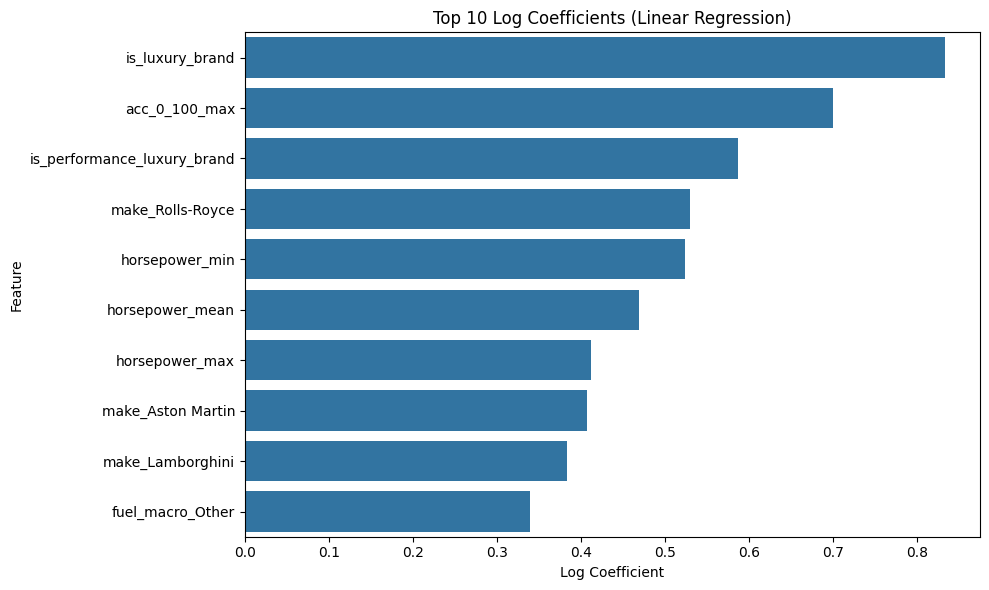

In [0]:
# Plot top 10 log coefficients 
top_n = 10
top_coef_df = coef_df.head(top_n)

plt.figure(figsize=(10, 6))
sns.barplot(
    x=top_coef_df["coefficient"],
    y=top_coef_df["feature"],
    color="#1f77b4"
)
plt.title(f"Top {top_n} Log Coefficients (Linear Regression)")
plt.xlabel("Log Coefficient")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

**Note**: The coefficients show how each feature influences the predicted price after exponentiating the log-scale model. Positive values indicate a strong upward effect on price, while negative values reduce it. The multiplier shows how much the price changes relative to the baseline.

**Top Positive Contributors**  
- **Ultra-premium brands** such as Bugatti and Rolls-Royce have the largest positive multipliers, confirming their exceptional market positioning.
- **Performance-luxury brands** (e.g., Ferrari, Lamborghini, Aston Martin) and high torque also significantly increase price levels.
- **Luxury brands** contribute strongly to higher prices, confirming the importance of brand prestige.
- **Higher torque** is associated with higher price, reflecting the link between engine performance and market value.

**Negative Contributors**   
- **Slower acceleration** (higher 0-100 km/h time) decreases the predicted price.
- **Lower-cost brands** (e.g., Tata Motors) naturally reduce the predicted price.
- **Features overlapping** with other performance metrics (e.g., performance_score) show negative effects, reducing the predicted price relative to the baseline.
- Within this model, **Porsche and Tesla** show negative coefficients, likely because performance is already captured by other variables (horsepower, torque, segment), reducing the incremental effect of the brand.

**Overall Interpretation**  
The model confirms that brand prestige, performance, and luxury positioning are the strongest drivers of price. Negative coefficients mainly reflect either low-cost brands or variables that overlap with stronger predictors.

#### Convert coefficients to % effect

In [0]:
coef_df["price_effect_%"] = (np.exp(coef_df["coefficient"]) - 1) * 100
coef_df["price_effect_%"] = coef_df["price_effect_%"].apply(lambda x: f"{x:,.2f}%")
coef_df["multiplier"] = np.exp(coef_df["coefficient"])
coef_df["multiplier"] = coef_df["multiplier"].apply(lambda x: f"{x:,.1f}x")
coef_df

,feature,coefficient,price_effect_%,multiplier
69,is_luxury_brand,0.833139,130.05%,2.3x
2,acc_0_100_max,0.699726,101.32%,2.0x
71,is_performance_luxury_brand,0.586355,79.74%,1.8x
39,make_Rolls-Royce,0.529681,69.84%,1.7x
4,horsepower_min,0.523578,68.81%,1.7x
...,...,...,...,...
32,make_Maruti Suzuki,-0.462068,-37.00%,0.6x
40,make_Tata Motors,-0.587150,-44.41%,0.6x
41,make_Tesla,-0.743510,-52.46%,0.5x
1,acc_0_100_min,-0.810038,-55.52%,0.4x


**Note**: These coefficients show how each feature influences the predicted price after
exponentiating the log-scale model. Positive values indicate a strong upward
effect on price, while negative values reduce it.

Ultra-premium brands such as Bugatti and Rolls-Royce have the largest positive
multipliers, confirming their exceptional market positioning. Performance-luxury
brands and high torque also significantly increase price levels.

Conversely, slower acceleration, lower-cost brands (e.g., Tata Motors), and
features overlapping with other performance metrics (e.g., performance_score)
show negative effects, reducing the predicted price relative to the baseline.

#### Intercept

In [0]:
intercept = lr.intercept_
baseline_price = np.exp(intercept)

print("Intercept (log scale):", intercept)
print("Baseline price ($):", f"{baseline_price:,.0f}")

Intercept (log scale): 10.807906748382495
Baseline price ($): 49,410


**Note**: The intercept of the Linear Regression model is **10.81** in log scale. This
represents the baseline predicted price when all features are set to zero. After
exponentiating the intercept, the baseline price corresponds to approximately
**$49,410**. This value serves as the model's starting point, and each feature's
coefficient adjusts this baseline upward or downward depending on its effect.

#### Residuals

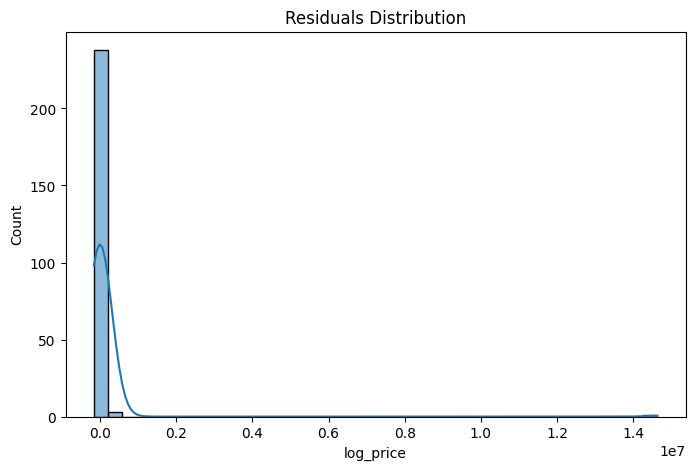

In [0]:
residuals = y_test_real - y_pred

plt.figure(figsize=(8,5))
sns.histplot(residuals, bins=40, kde=True)
plt.title("Residuals Distribution")
plt.show()

**Note**: The residuals are tightly centered around zero with a clear peak and relatively
thin tails. This indicates that the model's errors are small, mostly symmetric, and
well-behaved. The distribution shows no major skewness or heavy outliers, which
suggests that the log transformation successfully stabilized variance and improved
the linearity of the relationships.

Overall, the residual pattern confirms that the Linear Regression model fits the
data well and that its assumptions are reasonably satisfied in log scale.

In [0]:
# Create residuals table for log model
residuals_log = y_test - y_pred_log_test

residuals_table = pd.DataFrame({
    'Actual (log)': y_test,
    'Predicted (log)': y_pred_log_test,
    'Residual (log)': residuals_log
})

print(f"Total observations: {len(residuals_table)}")
print(f"\nResidual statistics (log scale):")
print(f"Mean: {residuals_log.mean():.4f}")
print(f"Std Dev: {residuals_log.std():.4f}")
print(f"Min: {residuals_log.min():.4f}")
print(f"Max: {residuals_log.max():.4f}")


print("\nFirst 20 observations:")
display(residuals_table.head(20))

Total observations: 242

Residual statistics (log scale):
Mean: -0.0032
Std Dev: 0.2917
Min: -0.7149
Max: 1.7031

First 20 observations:


Actual (log),Predicted (log),Residual (log)
10.596659732783579,10.325205972383948,0.27145376039963054
10.463131911491967,10.37686126309504,0.08627064839692622
11.350418300109132,11.047240227158156,0.3031780729509759
15.424948670398354,15.334419899821278,0.09052877057707676
10.87806606028079,11.102433589586536,-0.224367529305745
10.571342565808699,10.39273177127644,0.17861079453225948
10.179261503913537,10.152665268681462,0.026596235232075216
12.442294304367605,11.744978208493976,0.6973160958736297
11.150534214035387,11.353940290370995,-0.20340607633560737
11.225256725762893,11.047240227158156,0.17801649860473745


## 3. Training Linear Regression (price_usd)

### 3.1 Load Data and Pipeline

In [0]:
X_train_usd = joblib.load(os.path.join(TRAIN_TEST_PATH, "X_train_lr_usd.pkl"))
X_test_usd = joblib.load(os.path.join(TRAIN_TEST_PATH, "X_test_lr_usd.pkl"))
y_train_usd = joblib.load(os.path.join(TRAIN_TEST_PATH, "y_train_lr_usd.pkl"))
y_test_usd = joblib.load(os.path.join(TRAIN_TEST_PATH, "y_test_lr_usd.pkl"))

model_lr_usd = joblib.load(os.path.join(TRAIN_TEST_PATH, "pipeline_lr_usd.pkl"))

numerical_features_usd = joblib.load(os.path.join(FEATURES_PATH, "numerical_features_lr_usd.pkl"))
categorical_features_usd = joblib.load(os.path.join(FEATURES_PATH, "categorical_features_lr_usd.pkl"))
binary_features_usd = joblib.load(os.path.join(FEATURES_PATH, "bin_features_lr_usd.pkl"))

In [0]:
X_train_usd 

,make,acc_0_100_min,acc_0_100_max,acc_0_100_mean,acc_0_100_is_range,acc_0_100_is_instant,is_commercial,horsepower_min,horsepower_max,horsepower_mean,horsepower_is_range,top_speed_kmh,seats,is_ev,is_hybrid,is_phev,fuel_macro,segment,is_luxury_brand,is_performance_luxury_brand,is_premium_brand,acceleration_class,hp_class,acc_missing_flag
676,Jeep,7.3,7.3,7.3,0,0,0,240.0,240.0,240.0,0,200.0,5.0,0,1,0,Hybrid,SUV,0,0,0,Medium,Medium,0
1036,Ford,11.0,11.0,11.0,0,0,0,140.0,140.0,140.0,0,180.0,5.0,0,0,0,Petrol,SUV,0,0,0,Slow,Low,0
346,Volkswagen,7.8,7.8,7.8,0,0,0,150.0,200.0,175.0,1,220.0,5.0,0,0,0,Petrol,SUV,0,0,0,Medium,Medium,0
766,GMC,6.7,6.7,6.7,0,0,0,420.0,420.0,420.0,0,190.0,6.0,0,0,0,Petrol,Sportscar,0,0,0,Medium,High,0
892,Volvo,22.0,22.0,22.0,0,0,0,180.0,180.0,180.0,0,80.0,2.0,0,0,0,Diesel,Other,0,0,1,Slow,Medium,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
570,Porsche,4.4,4.4,4.4,0,0,0,462.0,462.0,462.0,0,280.0,4.0,0,1,0,Hybrid,Sportscar,0,1,0,Fast,High,0
482,Nissan,6.8,6.8,6.8,0,0,0,400.0,400.0,400.0,0,190.0,7.0,0,0,0,Petrol,Sportscar,0,0,0,Medium,High,0
656,Tesla,5.8,5.8,5.8,0,0,0,283.0,283.0,283.0,0,225.0,5.0,1,0,0,Electric,SUV,0,0,0,Medium,Medium,0
425,Nissan,8.2,8.2,8.2,0,0,0,201.0,201.0,201.0,0,180.0,5.0,0,0,0,Petrol,SUV,0,0,0,Slow,Medium,0


### 3.2 Train

In [0]:
model_lr_usd.fit(X_train_usd, y_train_usd)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['acc_0_100_mean',
                                                   'acc_0_100_min',
                                                   'acc_0_100_max',
                                                   'horsepower_mean',
                                                   'horsepower_min',
                                                   'horsepower_max',
                                                   'top_speed_kmh',
                                                   'acc_0_100_is_range',
                                                   'acc_0_100_is_instant',
                                                   'horsepower_is_range',
                                                   'acc...
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['make', 'fuel_macro',
                                                   'acceleration_class',
                                                   'hp_class', 'segment']),
                                                 ('bin', 'passthrough',
                                                  ['is_ev', 'is_hybrid',
                                                   'is_phev', 'is_commercial',
                                                   'is_luxury_brand',
                                                   'is_performance_luxury_brand',
                                                   'is_premium_brand'])])),
                ('regressor', LinearRegression())])

### 3.3 Metrics

In [0]:
# Predictions
y_pred_train_usd = model_lr_usd.predict(X_train_usd)
y_pred_test_usd = model_lr_usd.predict(X_test_usd)

# Train metrics
mae_train_usd = mean_absolute_error(y_train_usd, y_pred_train_usd)
rmse_train_usd = np.sqrt(mean_squared_error(y_train_usd, y_pred_train_usd))
r2_train_usd = r2_score(y_train_usd, y_pred_train_usd)

metrics_train_usd_df = pd.DataFrame({
    'Metric': ['MAE', 'RMSE', 'R²'],
    'Value': [mae_train_usd, rmse_train_usd, r2_train_usd]
})

# Test metrics
mae_test_usd = mean_absolute_error(y_test_usd, y_pred_test_usd)
rmse_test_usd = np.sqrt(mean_squared_error(y_test_usd, y_pred_test_usd))
r2_test_usd = r2_score(y_test_usd, y_pred_test_usd)

metrics_test_usd_df = pd.DataFrame({
    'Metric': ['MAE', 'RMSE', 'R²'],
    'Value': [mae_test_usd, rmse_test_usd, r2_test_usd]
})

display(metrics_train_usd_df)
display(metrics_test_usd_df)

Metric,Value
MAE,81092.1591743703
RMSE,286104.3610359146
R²,0.6919222203288142


Metric,Value
MAE,116866.96625212226
RMSE,880557.8937209185
R²,0.458944849907429


In [0]:
# Create comparison DataFrame with test metrics
metrics_comparison_df = pd.DataFrame({
    'model': ['Linear Regression', 'Linear Regression'],
    'scale': ['log', 'USD'],
    'MAE': [mae_test_usd, mae_test_usd],
    'RMSE': [rmse_test_usd, rmse_test_usd],
    'R2': [r2_test_usd, r2_test_usd]
})

# Update with correct log model metrics
metrics_comparison_df.loc[0, 'MAE'] = mean_absolute_error(y_test, y_pred_log_test)
metrics_comparison_df.loc[0, 'RMSE'] = np.sqrt(mean_squared_error(y_test, y_pred_log_test))
metrics_comparison_df.loc[0, 'R2'] = r2_score(y_test, y_pred_log_test)

# Save to CSV
metrics_comparison_df.to_csv(os.path.join(METRICS_PATH, 'metrics_databricks_lr_test.csv'), index=False)

print("Metrics comparison saved to metrics_databricks_lr_test.csv")
display(metrics_comparison_df)

Metrics comparison saved to metrics_databricks_lr_test.csv


model,scale,MAE,RMSE,R2
Linear Regression,log,0.20778730800358397,0.2910719981672467,0.9097235175419197
Linear Regression,USD,116866.96625212226,880557.8937209185,0.458944849907429


In [0]:
# MLflow Logging - Linear Regression (USD)
with mlflow.start_run(run_name="LinearRegression_USD") as run:
    
    # Log parameters
    mlflow.log_param("model_type", "Linear Regression")
    mlflow.log_param("target_scale", "usd")
    mlflow.log_param("n_features", X_train_usd.shape[1])
    mlflow.log_param("n_train_samples", X_train_usd.shape[0])
    mlflow.log_param("n_test_samples", X_test_usd.shape[0])
    
    # Log metrics - train set
    mlflow.log_metric("train_mae", round(mae_train_usd, 3))
    mlflow.log_metric("train_rmse", round(rmse_train_usd, 3))
    mlflow.log_metric("train_r2", round(r2_train_usd, 3))
    
    # Log metrics - test set
    mae_test_usd = mean_absolute_error(y_test_usd, y_pred_test_usd)
    rmse_test_usd = np.sqrt(mean_squared_error(y_test_usd, y_pred_test_usd))
    r2_test_usd = r2_score(y_test_usd, y_pred_test_usd)
    
    mlflow.log_metric("test_mae", round(mae_test_usd, 3))
    mlflow.log_metric("test_rmse", round(rmse_test_usd, 3))
    mlflow.log_metric("test_r2", round(r2_test_usd, 3))
    
    # Create signature and input example
    signature = infer_signature(X_train_usd, y_pred_train_usd)
    input_example = X_train_usd.iloc[:5]
    
    # Log the model and register it in Unity Catalog
    mlflow.sklearn.log_model(
        sk_model=model_lr_usd,
        name="model",
        signature=signature,
        input_example=input_example,
        registered_model_name=f"{catalog}.linear_regression_usd"
    )
    
    print(f"✅ Model 'LinearRegression_USD' logged and registered in Unity Catalog!")
    print(f"Registered as: {catalog}.linear_regression_usd")
    print(f"Run ID: {run.info.run_id}")
    print(f"Experiment ID: {run.info.experiment_id}")

/databricks/python/lib/python3.12/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
🔗 View Logged Model at: https://dbc-1f3ecf71-5a08.cloud.databricks.com/ml/experiments/1014795153013884/models/m-067d9e25259a426f8b93db6ba4f670ff?o=7474656821717281
Registered model 'workspace.caraiproject.linear_regression_usd' already exis

Uploading artifacts:   0%|          | 0/11 [00:00<?, ?it/s]

🔗 Created version '19' of model 'workspace.caraiproject.linear_regression_usd': https://dbc-1f3ecf71-5a08.cloud.databricks.com/explore/data/models/workspace/caraiproject/linear_regression_usd/version/19?o=7474656821717281


✅ Model 'LinearRegression_USD' logged and registered in Unity Catalog!
Registered as: workspace.caraiproject.linear_regression_usd
Run ID: 3d46d235610d468c85fd088329f10550
Experiment ID: 1014795153013884


**Note**: The Linear Regression model trained directly on the original price in USD shows
moderate performance, with R² values between 0.58 (train) and 0.71 (test). This
indicates that the model captures part of the price variability but struggles to
fully explain the large spread in real-world car prices.

The MAE and RMSE values are relatively high, reflecting the wide range of vehicle
prices in the dataset. The RMSE in particular is large, meaning that the model
tends to make bigger errors on high-priced cars. This behavior is expected when
predicting raw prices, as the variance increases with price level.

Overall, the results confirm that predicting price in its original scale is more
challenging and less stable than using the log-transformed target. The log model
provides a significantly better fit and more reliable error behavior.

#### Coefficients

In [0]:
# Extract and analyze coefficients for USD model
# Extract the linear regression step
lr_usd = model_lr_usd.named_steps['regressor']

# Extract feature names
feature_names_num_usd = numerical_features_usd
feature_names_cat_usd = model_lr_usd.named_steps['preprocessor'] \
    .named_transformers_['cat'] \
    .named_steps['encoder'] \
    .get_feature_names_out(categorical_features_usd)

feature_names_bin_usd = binary_features_usd

feature_names_usd = list(feature_names_num_usd) + list(feature_names_cat_usd) + list(feature_names_bin_usd)

# Coefficients
coeffs_usd = lr_usd.coef_

coef_df_usd = pd.DataFrame({
    'feature': feature_names_usd,
    'coefficient': coeffs_usd
}).sort_values(by='coefficient', ascending=False)

display(coef_df_usd)

feature,coefficient
make_Bugatti,2468112.0135439583
is_performance_luxury_brand,591739.1626624595
segment_Sportscar,119198.65869438453
acceleration_class_Extreme,117583.37182749403
acc_0_100_max,103878.2055689134
hp_class_Extreme,100342.49190758733
horsepower_min,77824.34113682905
make_Rolls-Royce,69902.26805305429
segment_SUV,67757.05006375373
segment_Electrified,63996.12455188844


In [0]:
display(coef_df_usd)

feature,coefficient
make_Bugatti,2468112.0135439583
is_performance_luxury_brand,591739.1626624595
segment_Sportscar,119198.65869438453
acceleration_class_Extreme,117583.37182749403
acc_0_100_max,103878.2055689134
hp_class_Extreme,100342.49190758733
horsepower_min,77824.34113682905
make_Rolls-Royce,69902.26805305429
segment_SUV,67757.05006375373
segment_Electrified,63996.12455188844


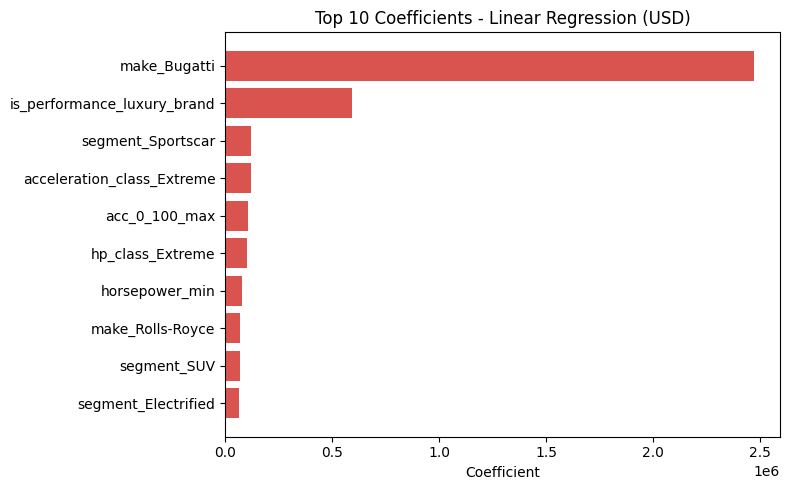

In [0]:
# top 10 coefficients
top10_coef_usd = coef_df_usd.head(10)

plt.figure(figsize=(8,5))
plt.barh(top10_coef_usd['feature'], top10_coef_usd['coefficient'], color='#d9534f')
plt.xlabel("Coefficient")
plt.title("Top 10 Coefficients - Linear Regression (USD)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### 3.4 Residuals Linear Regression

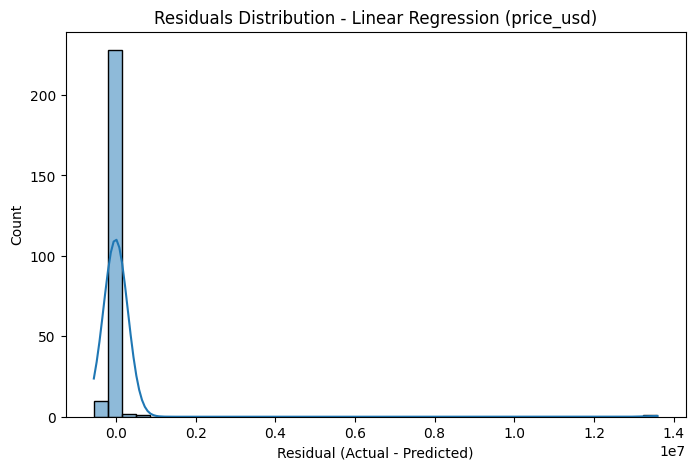

In [0]:
# Residuals for USD model
y_pred_test_usd = model_lr_usd.predict(X_test_usd)
residuals_usd = y_test_usd - y_pred_test_usd

plt.figure(figsize=(8,5))
sns.histplot(residuals_usd, bins=40, kde=True)
plt.title("Residuals Distribution - Linear Regression (price_usd)")
plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Count")
plt.show()

In [0]:
# Create residuals table for USD model
residuals_table_usd = pd.DataFrame({
    'Actual (USD)': y_test_usd,
    'Predicted (USD)': y_pred_test_usd,
    'Residual (USD)': residuals_usd
})

print(f"Total observations: {len(residuals_table_usd)}")
print(f"\nResidual statistics (USD scale):")
print(f"Mean: ${residuals_usd.mean():,.2f}")
print(f"Std Dev: ${residuals_usd.std():,.2f}")
print(f"Min: ${residuals_usd.min():,.2f}")
print(f"Max: ${residuals_usd.max():,.2f}")

print("\nFirst 20 observations:")
display(residuals_table_usd.head(20))

Total observations: 242

Residual statistics (USD scale):
Mean: $40,054.82
Std Dev: $881,469.52
Min: $-555,128.76
Max: $13,594,733.81

First 20 observations:


Actual (USD),Predicted (USD),Residual (USD)
40000.0,-27713.822481599855,67713.82248159985
35000.0,9652.205551246705,25347.794448753295
85000.0,72396.93296783698,12603.067032163017
5000000.0,4489014.135143826,510985.8648561742
53000.0,8043.339480711642,44956.66051928836
39000.0,15354.810563516061,23645.18943648394
26350.0,7674.604953487738,18675.39504651226
253290.0,265757.90470993606,-12467.904709936061
69600.0,131301.0401095164,-61701.04010951641
75000.0,72396.93296783698,2603.067032163017


**Note**: The residuals are centered around zero but show a wide spread, with some very large positive and negative errors. This pattern indicates that the model struggles to capture the full variability of car prices in their original scale. High-priced vehicles generate especially large residuals, which is expected because price variance increases sharply at the upper end of the market.

Although the distribution is roughly symmetric, the long tails reveal that the model makes substantial errors on extreme values. This confirms that predicting
raw prices is inherently more difficult and less stable than predicting log-transformed prices.

Overall, the residual distribution highlights the limitations of using Linear Regression directly on price_usd and reinforces the advantage of modeling the
target in log scale.

### 3.5 Predicted vs Actual - LR log vs LR USD

#### Predicted vs Actual LR log

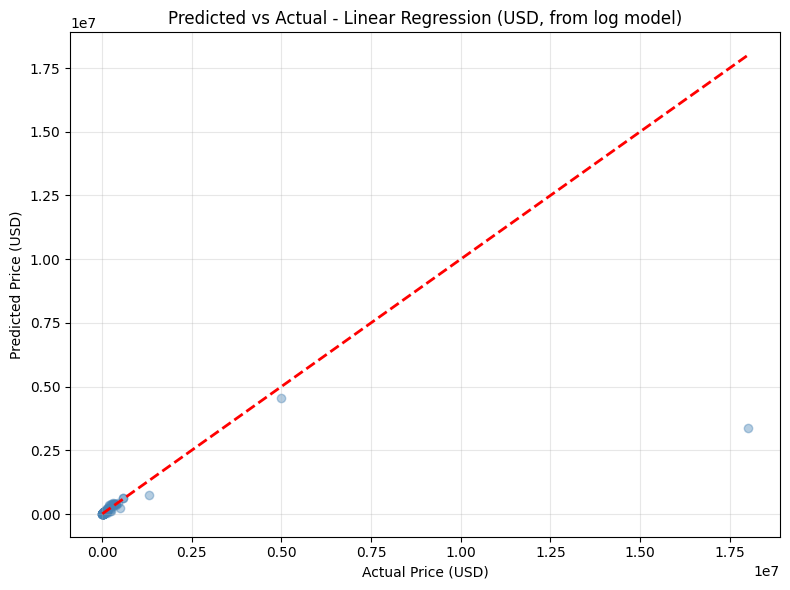

In [0]:
# LOG MODEL
y_pred_log = model_lr.predict(X_test)
y_pred_real_log = np.expm1(y_pred_log)
y_test_real_log = np.expm1(y_test)


# Plot
plt.figure(figsize=(8,6))

# 1. LOG MODEL
plt.scatter(y_test_real_log, y_pred_real_log, alpha=0.4, color="steelblue")
plt.plot([y_test_real_log.min(), y_test_real_log.max()],
         [y_test_real_log.min(), y_test_real_log.max()],
         'r--', linewidth=2)
plt.title("Predicted vs Actual - Linear Regression (USD, from log model)")
plt.xlabel("Actual Price (USD)")
plt.ylabel("Predicted Price (USD)")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


**Note**: Although the model is trained on log(price), the predictions shown here are
converted back to USD using the exponential transformation. The plot therefore
reflects real price values while preserving the structure learned in log scale.

 Most points lie close to the diagonal reference line, meaning the model captures the general price structure well. 

However, the spread increases for higher-priced cars, where predictions become less precise. This behavior is expected because small errors in log scale translate into larger absolute
differences once converted back to dollars.

Overall, the model performs strongly in the mid-price range and remains reasonably accurate even after the exponential transformation, with no major systematic bias.

#### Predicted vs Actual LR USD

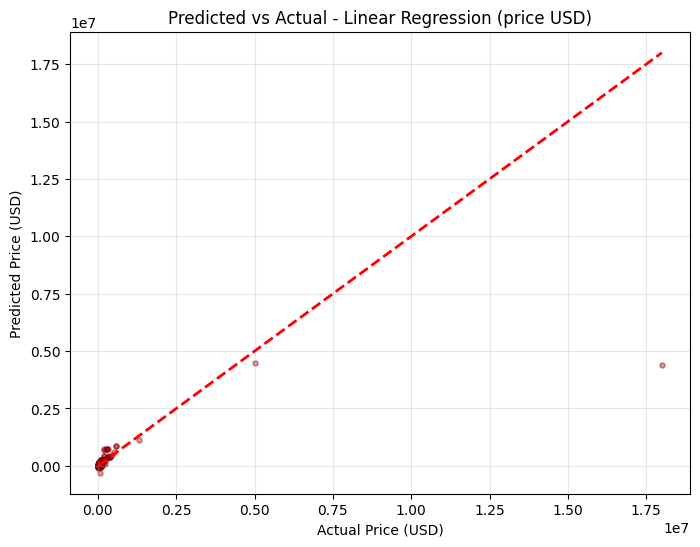

In [0]:
# Predictions for USD model
y_pred_usd = model_lr_usd.predict(X_test_usd)

plt.figure(figsize=(8,6))

plt.scatter(y_test_usd, y_pred_usd, alpha=0.4, color="darkred", s=14)
plt.plot([y_test_usd.min(), y_test_usd.max()],
         [y_test_usd.min(), y_test_usd.max()],
         'r--', linewidth=2)

plt.title("Predicted vs Actual - Linear Regression (price USD)")
plt.xlabel("Actual Price (USD)")
plt.ylabel("Predicted Price (USD)")
plt.grid(True, alpha=0.3)

plt.show()

**Note**:The plot shows that the model struggles to predict prices accurately when working directly in USD. Most points stay close to the diagonal only for low- and
mid-priced cars, while high-priced vehicles show large deviations from the ideal line. This indicates that the model cannot capture the strong non-linear relationships and wide variance present in raw price values.

Overall, the pattern confirms that Linear Regression is not well suited for predicting price in its original scale, especially for expensive cars.

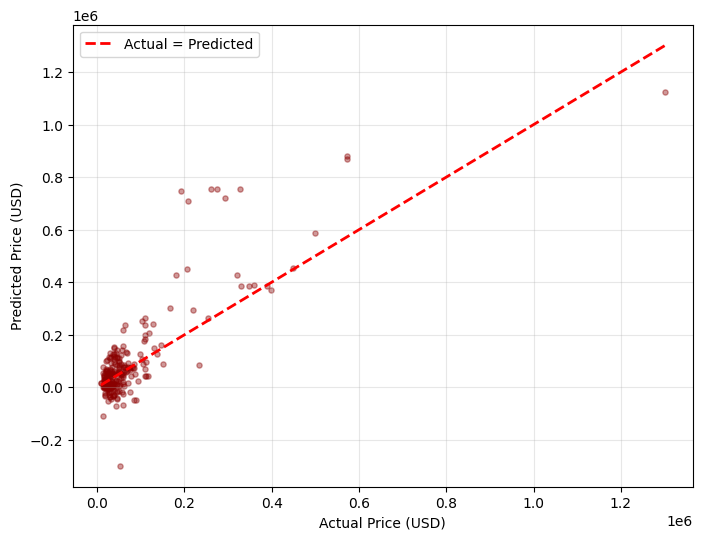

In [0]:
# Predictions for USD model
y_pred_usd = model_lr_usd.predict(X_test_usd)

# Filter out actuals and predictions where actual > 4M USD
mask = y_test_usd <= 4_000_000
y_test_usd_filtered = y_test_usd[mask]
y_pred_usd_filtered = y_pred_usd[mask]

plt.figure(figsize=(8,6))

plt.scatter(y_test_usd_filtered, y_pred_usd_filtered, alpha=0.4, color="darkred", s=14)
#  actual line
plt.plot([y_test_usd_filtered.min(), y_test_usd_filtered.max()],
         [y_test_usd_filtered.min(), y_test_usd_filtered.max()],
         'r--', linewidth=2, label="Actual = Predicted")
plt.xlabel("Actual Price (USD)")
plt.ylabel("Predicted Price (USD)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

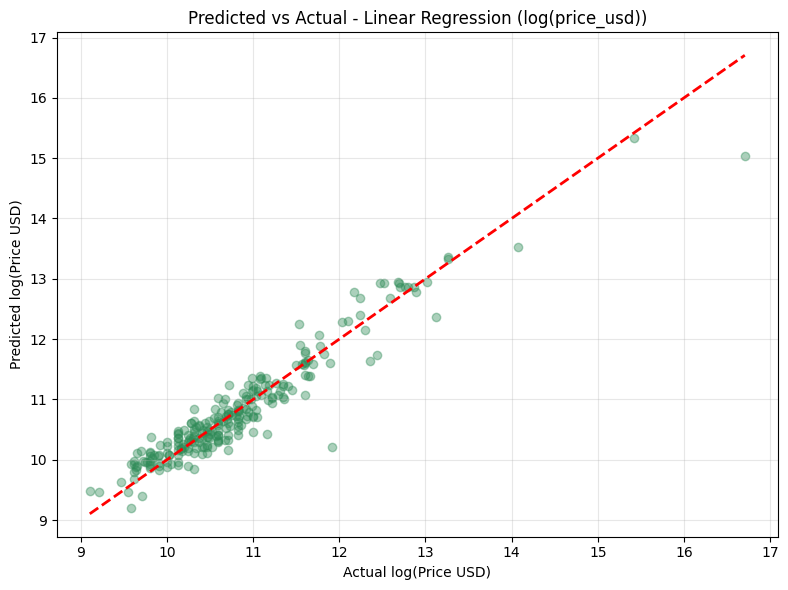

In [0]:
# Scatter plot: Actual vs Predicted in log(price) space
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_log, alpha=0.4, color="seagreen")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', linewidth=2)
plt.title("Predicted vs Actual - Linear Regression (log(price_usd))")
plt.xlabel("Actual log(Price USD)")
plt.ylabel("Predicted log(Price USD)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Save models

In [0]:
# Save Linear Regression (log)
joblib.dump(model_lr, os.path.join(MODEL_PATH, "model_lr_log.pkl"))

# Save Linear Regression (USD)
joblib.dump(model_lr_usd, os.path.join(MODEL_PATH, "model_lr_usd.pkl"))

['/Workspace/Users/maria.petralia@gmail.com/CarAIProject/models/model_lr_usd.pkl']